<a href="https://colab.research.google.com/github/marcodelibero/2026---Python-basics/blob/main/Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Let's master it by practicing 🦁 👑**

Most of the questions in this workbook were covered in the theory section. However there are some bonus 🎁 questions which were not fully covered and encourage you to google 🔍  and find your way around to learn even more !!

And don't worry if you are new to coding or not sure how something should be done from the top of your mind. Google and Nala are your best friend to assist! Always put on your critical thinking 🎩 on suggestions provided!

In [140]:
#importing general packages
import pandas as pd
import pandas_gbq
import pydata_google_auth
import scipy.stats
from scipy.stats import stats,kstest,mannwhitneyu, ttest_ind
from google.colab import drive



Today for practice we will be using open source scraped Airbnb data 🏠.

Download practice data from https://insideairbnb.com/get-the-data/ . Search for Stockholm data and download the listings.csv.gz and reviews.csv.gz data shown below: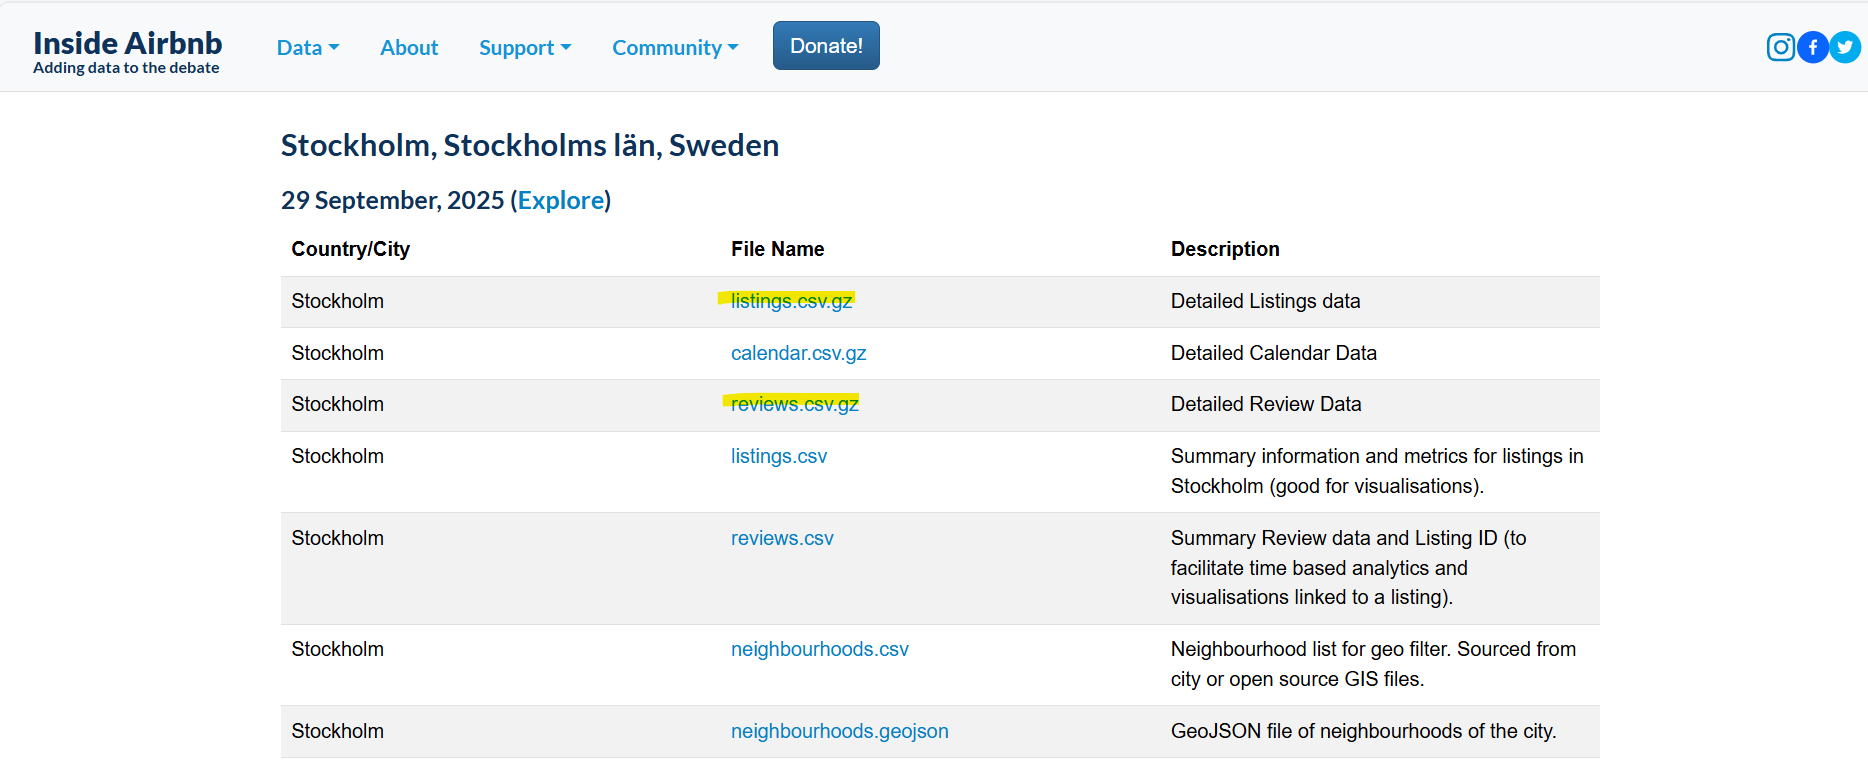

Once you downloaded it, you can simply upload the raw csv files to your Colab space from the left side:

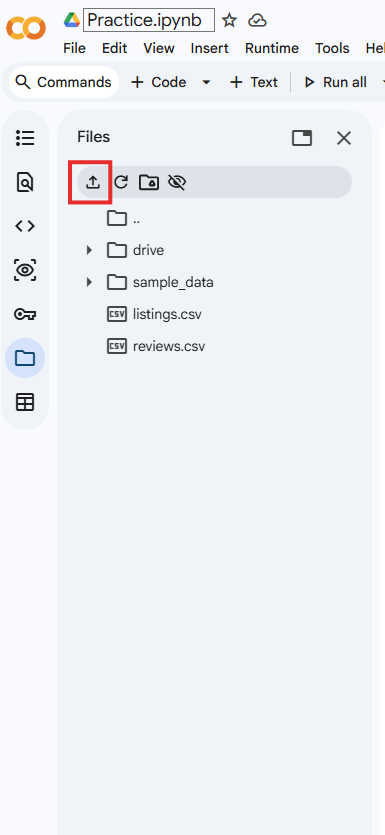

# Loading the data 🔢 .....


Full data dictionary for data being used can be found here ->  https://docs.google.com/spreadsheets/d/1iWCNJcSutYqpULSQHlNyGInUvHg2BoUGoNRIGa6Szc4/edit?gid=982310896#gid=982310896. But as a kick off in the listings data each row represnts a unique listing on AirBnb while in the reviews each row represents a unique review submitted.

In [50]:
listings_df= pd.read_csv('listings.csv')
reviews_df=pd.read_csv('reviews.csv')


In [17]:
listings_df.head(2)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,164448,https://www.airbnb.com/rooms/164448,20250929042406,2025-09-29,city scrape,Double room in central Stockholm with Wi-Fi,I am renting out a nice double room on the top floor in a large duplex apartment in the center of Stockholm at Södermalm. Close to metro and bus and walking distance to most of the sights.,NaN,https://a0.muscache.com/pictures/f56d8d10-a7fa-44d9-b521-b7a577abf327.jpg,784312,...,4.97,4.84,4.76,NaN,f,2,0,2,0,2.63
1,220851,https://www.airbnb.com/rooms/220851,20250929042406,2025-09-29,city scrape,One room in appartement,Welcome!,Many restaurangs wery close and walkingdistance To city.,https://a0.muscache.com/pictures/2085606/7a706118_original.jpg,412283,...,4.88,4.82,4.71,NaN,f,2,1,1,0,0.39


In [19]:
reviews_df.head(2)

,listing_id,id,date,reviewer_id,reviewer_name,comments
0,164448.0,407660.0,30/07/2011,870312,Fred,great fun at lidia's. she had the power adapter i needed. (try getting that at a hotel). and advice on stockholm. bright top floor and a quirky cork light switch worth the visit alone.
1,164448.0,451097.0,16/08/2011,901633,Julien,"Great centrally located room, very nice facilities. Everything was clean and tidy. I can only recommend this."


In [118]:
#from listings_df keeping only some relevant columns
listings_df=listings_df[['id', 'listing_url',  'name',
        'host_id',
       'host_since',
       'host_response_time', 'host_response_rate',
       'host_is_superhost',
       'neighbourhood_cleansed', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bedrooms', 'price']]

KeyError: "['price'] not in index"

In [45]:
listings_df.head(2)

,id,listing_url,name,host_id,host_since,host_response_time,host_response_rate,host_is_superhost,neighbourhood_cleansed,property_type,room_type,accommodates,bathrooms,bedrooms,daily_price_sek,host_since_year
0,164448,https://www.airbnb.com/rooms/164448,Double room in central Stockholm with Wi-Fi,784312,2011-07-06,within an hour,100%,t,Södermalms,Private room in rental unit,Private room,2,1.0,1.0,917.0,2011.0
1,220851,https://www.airbnb.com/rooms/220851,One room in appartement,412283,2011-02-27,a few days or more,0%,f,Kungsholmens,Private room in rental unit,Private room,1,1.0,1.0,450.0,2011.0


# As per data dictionary, the price is the daily price in local currency and $ sign is a technical issue of the export.

In [51]:
#cleaning price column from $ and ,
listings_df['price']=listings_df['price'].str.replace('$','',regex=False)
listings_df['price']=listings_df['price'].str.replace(',','',regex=False)

In [27]:
listings_df.head(2)

,id,listing_url,name,host_id,host_since,host_response_time,host_response_rate,host_is_superhost,neighbourhood_cleansed,property_type,room_type,accommodates,bathrooms,bedrooms,price
0,164448,https://www.airbnb.com/rooms/164448,Double room in central Stockholm with Wi-Fi,784312,2011-07-06,within an hour,100%,t,Södermalms,Private room in rental unit,Private room,2,1.0,1.0,917.00
1,220851,https://www.airbnb.com/rooms/220851,One room in appartement,412283,2011-02-27,a few days or more,0%,f,Kungsholmens,Private room in rental unit,Private room,1,1.0,1.0,450.00


# Check the data type of the columns in the `listings_df` dataset.

In [46]:
#check data types
listings_df.dtypes

,0
id,int64
listing_url,object
name,object
host_id,int64
host_since,datetime64[ns]
host_response_time,object
host_response_rate,object
host_is_superhost,object
neighbourhood_cleansed,object
property_type,object


# ↩ Change the `price` 💸 column to datatype float.

In [52]:
#insert code
listings_df['price']=listings_df['price'].astype('float')

# ❓ Check for missing data  counts in each column

In [47]:
listings_df.isna().sum()

,0
id,0
listing_url,0
name,0
host_id,0
host_since,4
host_response_time,1576
host_response_rate,1576
host_is_superhost,28
neighbourhood_cleansed,0
property_type,0


# In `listings_df` change the `price` column name to 'daily_price_sek'

In [53]:
#insert code
listings_df.rename(columns={'price':'daily_price_sek'},inplace=True)

#↩ Replace missing data as follows:

*   in price column by price mean
*   host_since by yesterday's date







In [54]:
#enter code
listings_df['daily_price_sek'].mean()

np.float64(1690.4730407523512)

In [55]:
#replacing missing data
listings_df['daily_price_sek']=listings_df['daily_price_sek'].fillna(1690)
listings_df['host_since']=listings_df['host_since'].fillna('2026-03-31')

# Add a column to the `listings_df`  to indicate the year host signed up. Name column `host_since_year`.

In [56]:
#code is provided
listings_df['host_since_year']=listings_df['host_since'].dt.year

AttributeError: Can only use .dt accessor with datetimelike values

# You get an error ❌. Can you try to understand what is creating the error and fix the code 🤔  

In [57]:
#enter code
listings_df['host_since']=pd.to_datetime(listings_df['host_since'])
listings_df['host_since_year']=listings_df['host_since'].dt.year

In [42]:
listings_df.head(2)

,id,listing_url,name,host_id,host_since,host_response_time,host_response_rate,host_is_superhost,neighbourhood_cleansed,property_type,room_type,accommodates,bathrooms,bedrooms,daily_price_sek,host_since_year
0,164448,https://www.airbnb.com/rooms/164448,Double room in central Stockholm with Wi-Fi,784312,2011-07-06,within an hour,100%,t,Södermalms,Private room in rental unit,Private room,2,1.0,1.0,917.0,2011.0
1,220851,https://www.airbnb.com/rooms/220851,One room in appartement,412283,2011-02-27,a few days or more,0%,f,Kungsholmens,Private room in rental unit,Private room,1,1.0,1.0,450.0,2011.0


# Change data type of `host_since_year` to int64

In [59]:
#enetr code
listings_df['host_since_year']=listings_df['host_since_year'].astype('int64')

# Determine the number of listings, broken down by the year host signed up.

In [61]:
#enter code
listings_df.groupby('host_since_year')['id'].count()

,id
host_since_year,
2008,1
2009,4
2010,10
2011,98
2012,182
2013,392
2014,551
2015,643
2016,650


# Bonus🎁: Order `host_since_year` in descending order of listings counts.

In [62]:
#enter code
listings_df.groupby('host_since_year')['id'].count().sort_values(ascending=False)


,id
host_since_year,
2016,650
2015,643
2014,551
2019,398
2013,392
2017,368
2023,318
2018,290
2024,247


# Bonus 🎁: Find % of total listings by host_since_year

In [69]:
#enter code
listings_df.groupby('host_since_year')['id'].count().sum(
)
grouped_data=(listings_df.groupby('host_since_year')['id'].count()/4955)*100
grouped_data


,id
host_since_year,
2008,0.020182
2009,0.080727
2010,0.201816
2011,1.977800
2012,3.673058
2013,7.911201
2014,11.120081
2015,12.976791
2016,13.118063


# Bonus 🎁: Add a column in `listings_df` to find the difference in days between today and the `host_since`. Name new column as `days_since_host_signup`.

In [70]:
#enter code
listings_df['days_since_host_signup']=(pd.to_datetime('2026-03-31')-listings_df['host_since']).dt.days

# Let's have a look at the daily price distribution 📊

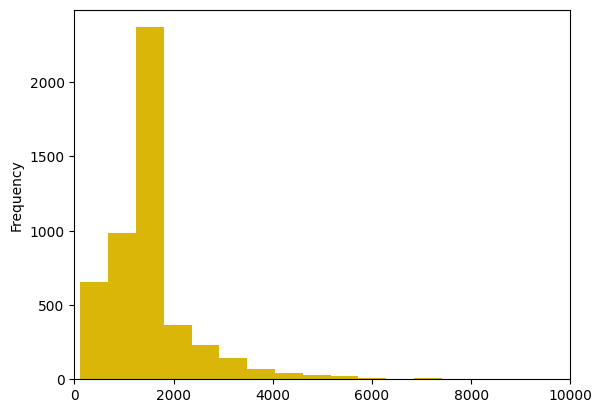

In [85]:
#checking distribution of price with a chart
#limit x-axis to 20000
import matplotlib.pyplot as plt
listings_df['daily_price_sek'].plot(kind='hist', bins=200,color='#d9b608')
plt.xlim(0, 10000)
plt.show()


In [86]:
listings_df['daily_price_sek'].describe()

,daily_price_sek
count,4955.000000
mean,1690.304541
std,2972.399760
min,120.000000
25%,984.000000
50%,1690.000000
75%,1690.000000
max,112218.000000


# 🪣 Create a column in the `listings_df` that buckets the `daily_price_sek` into the following buckets in days: [0, 1000, 1500, 1600, 1600+]. Give the correspondings labels ['low','medium', 'high', 'very_high'] Name column as `daily_price_sek_bucketed_tier`.

In [91]:
#enter code
price_buckets=[0,1000,1500,1600,float('inf')]
price_labels=['low','medium','high','very_high']
listings_df['daily_price_sek_bucketed_tier']=pd.cut(listings_df['daily_price_sek'],bins=price_buckets,labels=price_labels)

In [92]:
listings_df[['daily_price_sek','daily_price_sek_bucketed_tier']]

,daily_price_sek,daily_price_sek_bucketed_tier
0,917.0,low
1,450.0,low
2,1073.0,medium
3,779.0,low
4,2352.0,very_high
...,...,...
4950,567.0,low
4951,272.0,low
4952,657.0,low
4953,819.0,low


# 🔍 Find out how many listings fall into each bucket

In [93]:
#enter code
listings_df.groupby('daily_price_sek_bucketed_tier')['id'].count()

/tmp/ipykernel_2879/2560946679.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  listings_df.groupby('daily_price_sek_bucketed_tier')['id'].count()


,id
daily_price_sek_bucketed_tier,
low,1297
medium,671
high,95
very_high,2892


# 🔎 Filter for `listings_df` where neighbourhood_cleansed='Södermalms' and proprty_type='Entire rental unit'. Name the filtered dataset as `focus_group`.

In [116]:
#enter code
focus_group=listings_df[(listings_df['neighbourhood_cleansed']=='Södermalms') & (listings_df['property_type']=='Entire rental unit')]

In [117]:
listings_df.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'daily_price_sek',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg

# ⚠ Exclude observations in the focus_group where `host_is_superhost` is null.

In [131]:
#enter code
focus_group=focus_group[focus_group['host_is_superhost'].notna()]

# 🧪 Perform a statistical test within the `focus_group` to determine whether listings from superhosts (`host_is_superhost=t`) have a statistically significant higher price or not.

😽Tip! Here we have **unpaired data**, **2 groups** (host_is_superhost=t/f) and **quite a few observations**. We can kick off by performing a Kolmogorov-Smirnov test (using ks.test()). If data is normal, we can use an Independent Samples t-Test (using ttest_ind), otherwise a Mann- Whitney test (using mannwhitneyu() )would be viable.


In [135]:
#enter code
sh_yes=focus_group[focus_group['host_is_superhost']=='t']['daily_price_sek']
sh_no=focus_group[focus_group['host_is_superhost']=='f']['daily_price_sek']

In [136]:
sh_yes

,daily_price_sek
5,1126.0
74,1611.0
88,3950.0
94,3100.0
103,1150.0
...,...
4814,1677.0
4818,1851.0
4935,1103.0
4946,1229.0


In [145]:
#Normality Check
superhost_norm = (sh_yes - sh_yes.mean()) / sh_yes.std()
non_superhost_norm = (sh_no - sh_no.mean()) / sh_no.std()

ks_super = kstest(superhost_norm, 'norm')
ks_non = kstest(non_superhost_norm, 'norm')


In [146]:
ks_super

KstestResult(statistic=np.float64(0.20397781709507196), pvalue=np.float64(1.8200789335030982e-08), statistic_location=np.float64(-0.0936619471241846), statistic_sign=np.int8(1))

In [147]:
ks_non

KstestResult(statistic=np.float64(0.2840272681471879), pvalue=np.float64(1.1225762536384172e-50), statistic_location=np.float64(-0.06483681693569877), statistic_sign=np.int8(1))

p-value < 0.05 indicating that distributions are close to normal so we can perform a Mann-Whitney U-test



In [144]:
u_stat, p_val = mannwhitneyu(sh_yes, sh_no, alternative='greater')
print(p_val)

0.623348171904495


p-value>0.05 then there is no statistically significant difference in price of listings of superhosts and non superhosts.

# We have reviews data in `reviews_df`. For each review, create a column with the `property_type` and `host_is_super_host`. Name new columns in the review_df accordingly.

In [154]:
#enter code
reviews_df=pd.merge(reviews_df, listings_df[['id','host_is_superhost','property_type']],how='left',left_on='listing_id',right_on='id')
